## Fraud Detection using Random Forest
This notebook demonstrates how to build a fraud detection model using the PaySim dataset and a Random Forest Classifier.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load the full dataset (6.3M+ rows)
# We specify engine='c' for faster loading of large files
df = pd.read_csv('/content/paysim.csv')

print(f'\033[1mDataset Loaded Successfully\033[0m')
print(f'Total Rows: {len(df):,}')
print(f'Total Columns: {len(df.columns)}')
display(df.head())

Dataset Loaded Successfully
Total Rows: 6,362,620
Total Columns: 11


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


### Data Preprocessing
We need to handle categorical variables like `type` and drop columns that won't help the model generalize (like names of accounts).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Pre-Cleaning Audit: Check for nulls in target columns
null_report = df[['nameOrig', 'nameDest', 'amount']].isnull().sum()
print("--- Pre-Cleaning Null Count ---")
print(null_report)

# 2. Tracking original size
initial_row_count = len(df)

# 3. Strict Cleaning: Drop rows missing origin name, destination name, or amount
df.dropna(subset=['nameOrig', 'nameDest', 'amount'], inplace=True)

# 4. Smart Imputation for remaining features
# Numeric: Fill missing with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Categorical: Fill missing with "Unknown" instead of mode (flags missing data as a potential risk)
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna("Unknown")

# 5. Handle duplicates
df.drop_duplicates(inplace=True)
post_dedup_count = len(df)

# 6. Targeted Dropping & Native Categorical Casting
# Drop the useless rule-based flag, but KEEP the identifiers
df_clean = df.drop(['isFlaggedFraud'], axis=1, errors='ignore')

# Cast strings to 'category' datatype instead of using pd.get_dummies
# This allows models like LightGBM/XGBoost to handle them natively without bloating the dataset
cols_to_cast = ['type', 'nameOrig', 'nameDest']
for col in cols_to_cast:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# 7. Final Split
X = df_clean.drop('isFraud', axis=1)
y = df_clean['isFraud']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Results Summary
rows_deleted = initial_row_count - post_dedup_count
print(f'\n\033[1mData Integrity Report\033[0m')
print(f'Initial Rows: {initial_row_count:,}')
print(f'Rows Deleted (Strict Criteria + Duplicates): {rows_deleted:,}')
print(f'Final Rows Preserved: {len(df_clean):,}')

--- Pre-Cleaning Null Count ---
nameOrig    0
nameDest    0
amount      0
dtype: int64

Data Integrity Report
Initial Rows: 6,362,620
Rows Deleted (Strict Criteria + Duplicates): 0
Final Rows Preserved: 6,362,620


## ⚖️ Feature Scaling
Scaling ensures that features with larger magnitudes (like `amount`) don't disproportionately influence the model's weight distribution, which is critical for many ML algorithms.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

# Initialize the RobustScaler
scaler = RobustScaler()

# 1. Determine which dataset to use
try:
    X_train_base = X_train_selected.copy() if hasattr(X_train_selected, 'copy') else np.copy(X_train_selected)
    X_test_base = X_test_selected.copy() if hasattr(X_test_selected, 'copy') else np.copy(X_test_selected)
    print("Preparing to scale SELECTED features.")
except NameError:
    X_train_base = X_train.copy()
    X_test_base = X_test.copy()
    print("Preparing to scale ALL features ")

# 2. Check data type and scale accordingly
if isinstance(X_train_base, np.ndarray):
    # If it is a NumPy array, feature selection already turned everything into numbers.
    # We can safely scale the entire array.
    X_train_scaled = scaler.fit_transform(X_train_base)
    X_test_scaled = scaler.transform(X_test_base)
    print("Data is a NumPy array. Robust scaling applied to the entire array.")

else:
    # If it is a pandas DataFrame, isolate only the numeric columns to protect our 'category' text columns
    numeric_cols = X_train_base.select_dtypes(include=[np.number]).columns

    X_train_scaled = X_train_base.copy()
    X_test_scaled = X_test_base.copy()

    X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_base[numeric_cols])
    X_test_scaled[numeric_cols] = scaler.transform(X_test_base[numeric_cols])
    print(f"Data is a DataFrame. Robust scaling applied successfully to {len(numeric_cols)} numeric columns.")

Preparing to scale ALL features 
Data is a DataFrame. Robust scaling applied successfully to 6 numeric columns.


In [ ]:
import pandas as pd

print("Cleaning numeric columns and removing hidden strings...")

# List of columns that MUST be pure math numbers
ledger_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in ledger_cols:
    if col in df.columns:
        # errors='coerce' forces any strings (like "Unknown" or typos) to turn into NaN
        # .fillna(0) then replaces those NaNs with a safe numerical zero
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print("Data types successfully forced to numeric. You are clear to run the EDA cell!")

Cleaning numeric columns and removing hidden strings...
Data types successfully forced to numeric. You are clear to run the EDA cell!


## 📊 Exploratory Data Analysis (EDA)
Before building the model, let's visualize the data to understand the underlying patterns of fraudulent behavior.

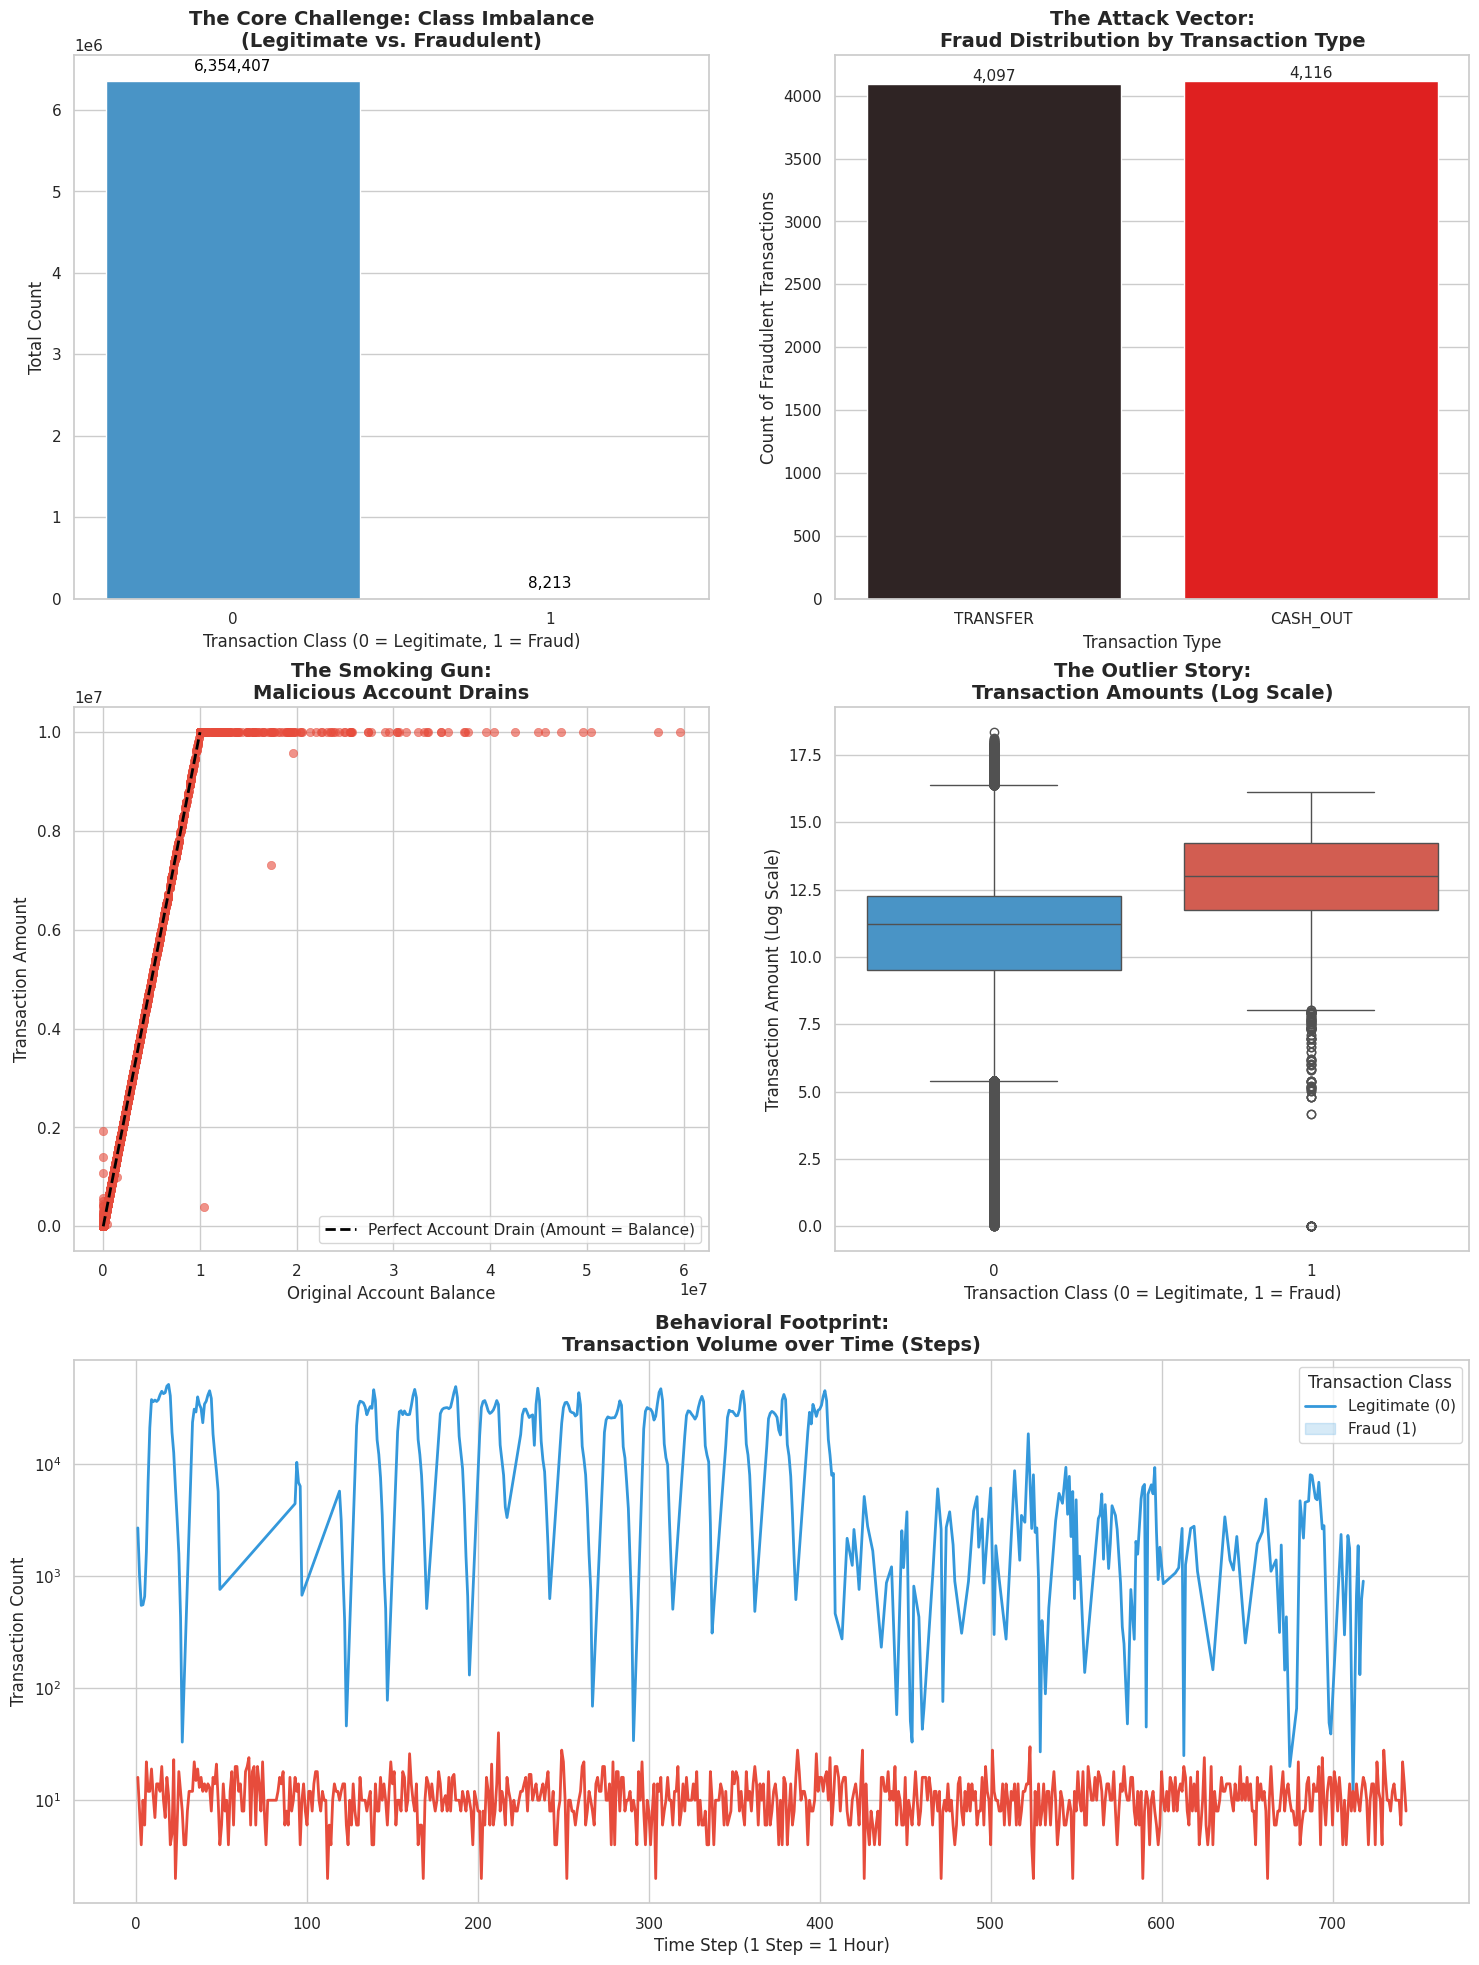

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a professional visual style for the hackathon presentation
sns.set_theme(style="whitegrid", palette="muted")

# Create a figure with subplots
fig = plt.figure(figsize=(18, 24))
fig.tight_layout(pad=6.0)

# ==========================================
# 1. The Setup: Class Imbalance Bar Chart
# ==========================================
plt.subplot(3, 2, 1)
# FIXED: Added hue='isFraud' and legend=False
ax1 = sns.countplot(x='isFraud', hue='isFraud', data=df, palette=['#3498db', '#e74c3c'], legend=False)
plt.title('The Core Challenge: Class Imbalance\n(Legitimate vs. Fraudulent)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Total Count', fontsize=12)
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

# ==========================================
# 2. The Deep Dive: Fraud strictly by Transaction Type
# ==========================================
plt.subplot(3, 2, 2)
fraud_df = df[df['isFraud'] == 1]
# FIXED: Added hue='type' and legend=False
ax2 = sns.countplot(x='type', hue='type', data=fraud_df, palette='dark:red', legend=False)
plt.title('The Attack Vector:\nFraud Distribution by Transaction Type', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Type', fontsize=12)
plt.ylabel('Count of Fraudulent Transactions', fontsize=12)
for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=11)

# ==========================================
# 3. The Smoking Gun: The "Account Drain" Scatter Plot
# ==========================================
plt.subplot(3, 2, 3)
sns.scatterplot(x='oldbalanceOrg', y='amount', data=fraud_df, color='#e74c3c', alpha=0.6, edgecolor=None)
max_val = min(fraud_df['oldbalanceOrg'].max(), fraud_df['amount'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Account Drain (Amount = Balance)')
plt.title('The Smoking Gun:\nMalicious Account Drains', fontsize=14, fontweight='bold')
plt.xlabel('Original Account Balance', fontsize=12)
plt.ylabel('Transaction Amount', fontsize=12)
plt.legend()

# ==========================================
# 4. The Outlier Story: Transaction Amount Boxplots
# ==========================================
plt.subplot(3, 2, 4)
df_vis = df.copy()
df_vis['log_amount'] = np.log1p(df_vis['amount'])
# FIXED: Added hue='isFraud' and legend=False
sns.boxplot(x='isFraud', y='log_amount', hue='isFraud', data=df_vis, palette=['#3498db', '#e74c3c'], legend=False)
plt.title('The Outlier Story:\nTransaction Amounts (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Transaction Amount (Log Scale)', fontsize=12)

# ==========================================
# 5. The Behavioral Pattern: Time-Series Line Chart (step)
# ==========================================
plt.subplot(3, 1, 3)
time_series = df.groupby(['step', 'isFraud']).size().reset_index(name='count')
sns.lineplot(x='step', y='count', hue='isFraud', data=time_series, palette=['#3498db', '#e74c3c'], linewidth=2)
plt.title('Behavioral Footprint:\nTransaction Volume over Time (Steps)', fontsize=14, fontweight='bold')
plt.xlabel('Time Step (1 Step = 1 Hour)', fontsize=12)
plt.ylabel('Transaction Count', fontsize=12)
plt.yscale('log')
plt.legend(title='Transaction Class', labels=['Legitimate (0)', 'Fraud (1)'])

plt.show()

## 🛠️ Advanced Feature Engineering
In fraud detection, the relationship between `oldbalance` and `newbalance` often reveals anomalies. We calculate the 'Balance Error' to highlight these discrepancies.

In [ ]:
import pandas as pd
import numpy as np

print("Initiating Advanced Feature Engineering...")

# 1. 🛡️ THE SANITIZER: Force df_clean ledger columns to be pure math numbers
ledger_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'step']
for col in ledger_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0)
print("Sanitized df_clean columns to pure numeric.")

# 2. Sort by Time: Crucial for network tracking to prevent data leakage from the future
df_clean = df_clean.sort_values(by='step').reset_index(drop=True)

# 3. The Core Ledger Errors
df_clean['errorBalanceOrig'] = df_clean['newbalanceOrig'] + df_clean['amount'] - df_clean['oldbalanceOrg']
df_clean['errorBalanceDest'] = df_clean['oldbalanceDest'] + df_clean['amount'] - df_clean['newbalanceDest']

# 4. The Account Drain Flag
df_clean['is_account_drain'] = np.where(df_clean['amount'] == df_clean['oldbalanceOrg'], 1, 0)

# 5. Time-of-Day Risk
df_clean['hour_of_day'] = df_clean['step'] % 24

# 6. Destination Velocity (Cumulative Volume)
df_clean['Dest_Total_Received_Volume'] = df_clean.groupby('nameDest', observed=True)['amount'].cumsum()

# 7. Mule Suspect Tracking
first_receipt = df_clean.groupby('nameDest', observed=True)['step'].min().to_dict()
df_clean['orig_first_receipt_step'] = df_clean['nameOrig'].map(first_receipt)

df_clean['is_Mule_Suspect'] = np.where(
    (df_clean['orig_first_receipt_step'].notna()) &
    (df_clean['step'] > df_clean['orig_first_receipt_step']),
    1, 0
)

# Clean up the temporary column
df_clean.drop('orig_first_receipt_step', axis=1, inplace=True)

print("Feature Engineering Complete. 6 High-Impact Features Added:")
print(list(df_clean.columns[-6:]))

Initiating Advanced Feature Engineering...
Sanitized df_clean columns to pure numeric.
Feature Engineering Complete. 6 High-Impact Features Added:
['errorBalanceOrig', 'errorBalanceDest', 'is_account_drain', 'hour_of_day', 'Dest_Total_Received_Volume', 'is_Mule_Suspect']


##The "Feature Impact Dashboard"
Let us see the features we have added

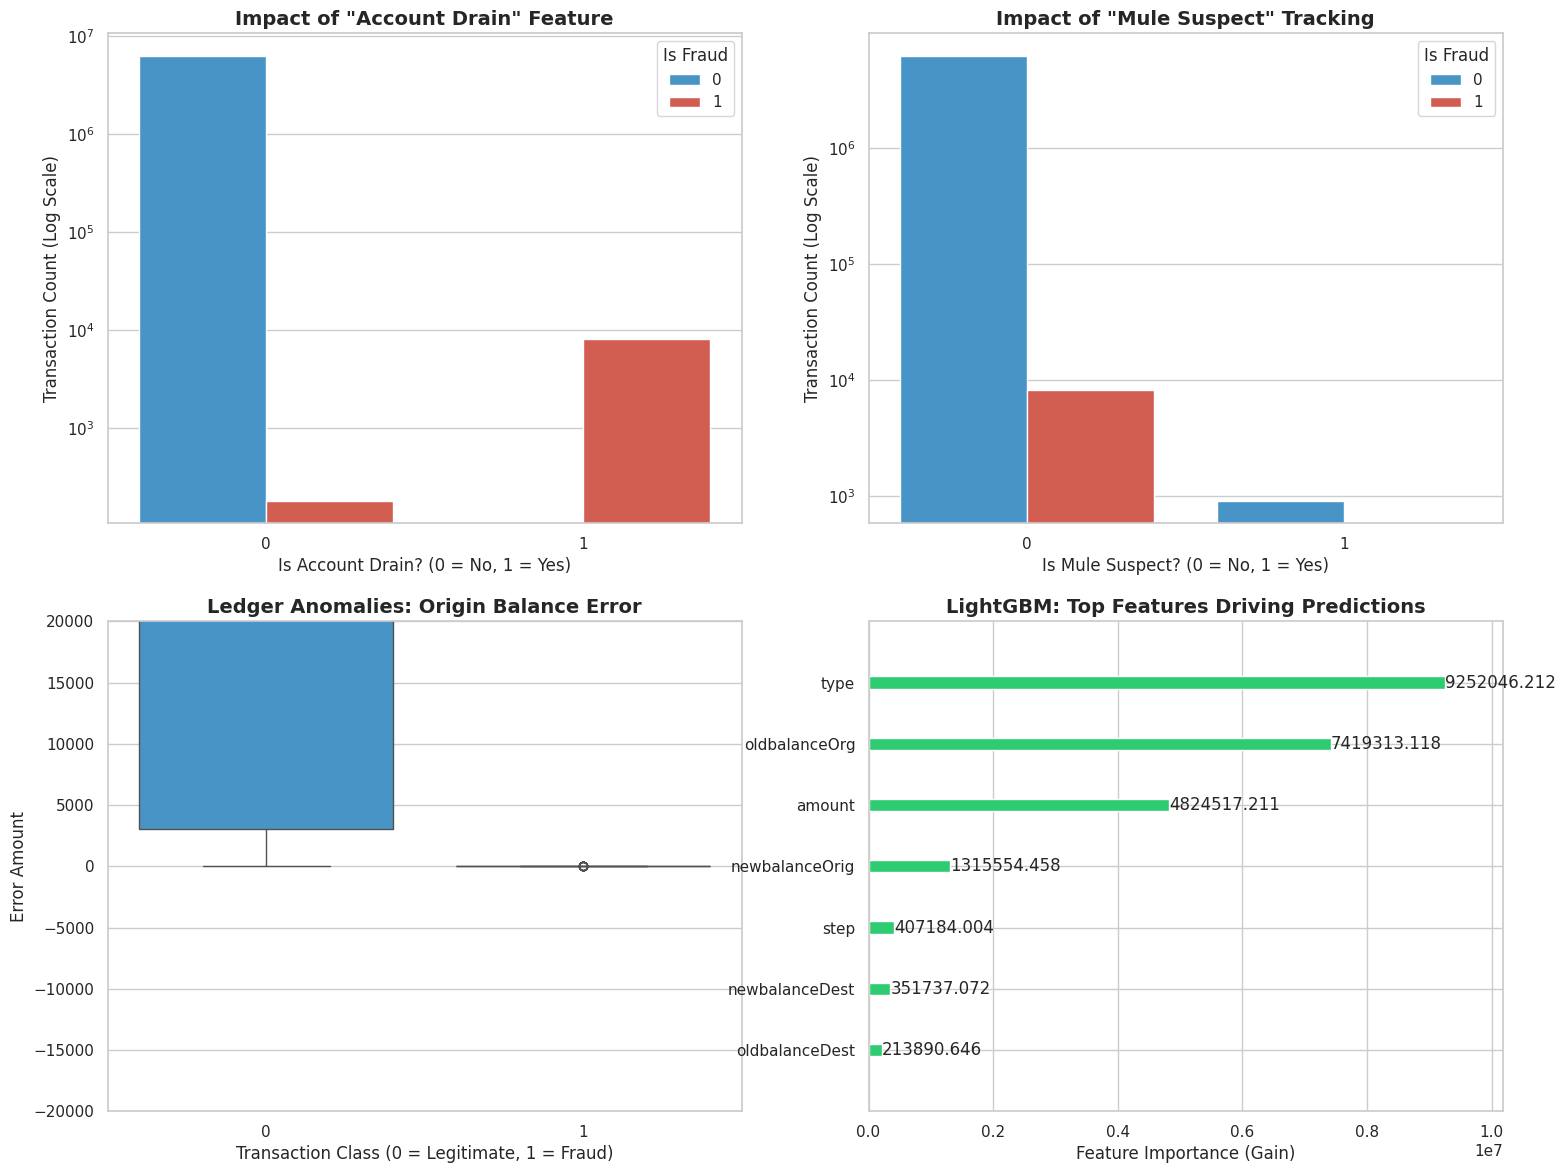

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the figure for the judges
sns.set_theme(style="whitegrid", palette="muted")
fig = plt.figure(figsize=(18, 14))
fig.tight_layout(pad=6.0)

# ==========================================
# 1. The Account Drain Flag Indicator
# ==========================================
plt.subplot(2, 2, 1)
# Using log scale because legitimate transactions dwarf fraud
ax1 = sns.countplot(x='is_account_drain', hue='isFraud', data=df_clean, palette=['#3498db', '#e74c3c'])
plt.title('Impact of "Account Drain" Feature', fontsize=14, fontweight='bold')
plt.xlabel('Is Account Drain? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Transaction Count (Log Scale)', fontsize=12)
plt.yscale('log')
plt.legend(title='Is Fraud', loc='upper right')

# ==========================================
# 2. Money Mule Suspect Distribution
# ==========================================
plt.subplot(2, 2, 2)
ax2 = sns.countplot(x='is_Mule_Suspect', hue='isFraud', data=df_clean, palette=['#3498db', '#e74c3c'])
plt.title('Impact of "Mule Suspect" Tracking', fontsize=14, fontweight='bold')
plt.xlabel('Is Mule Suspect? (0 = No, 1 = Yes)', fontsize=12)
plt.ylabel('Transaction Count (Log Scale)', fontsize=12)
plt.yscale('log')
plt.legend(title='Is Fraud', loc='upper right')

# ==========================================
# 3. Origin Balance Errors (Boxplot)
# ==========================================
plt.subplot(2, 2, 3)
# Limiting the Y-axis to zoom in on the core distributions, ignoring extreme outliers
sns.boxplot(x='isFraud', y='errorBalanceOrig', hue='isFraud', data=df_clean, palette=['#3498db', '#e74c3c'], legend=False)
plt.title('Ledger Anomalies: Origin Balance Error', fontsize=14, fontweight='bold')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)', fontsize=12)
plt.ylabel('Error Amount', fontsize=12)
plt.ylim(-20000, 20000)

# ==========================================
# 4. Feature Importance (Assuming lgb_model is trained)
# ==========================================
plt.subplot(2, 2, 4)
# If your model isn't named lgb_model, change the variable below
try:
    lgb.plot_importance(lgb_model, max_num_features=8, importance_type='gain', ax=plt.gca(), color='#2ecc71')
    plt.title('LightGBM: Top Features Driving Predictions', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Importance (Gain)', fontsize=12)
    plt.ylabel('')
except NameError:
    plt.text(0.5, 0.5, 'Run this after training the LightGBM model\\nto see Feature Importance',
             horizontalalignment='center', verticalalignment='center', fontsize=12)

plt.show()

### Model Training
Now we initialize and train the Random Forest model. Random Forest is often better at capturing non-linear relationships than Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Preparing data for Random Forest (Applying strict numeric filter)...")

# 1. Make fresh copies
X_train_rf = X_train_scaled.copy()
X_test_rf = X_test_scaled.copy()

# 2. Encode ONLY the 'type' column into numbers
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_rf['type'] = encoder.fit_transform(X_train_rf[['type']].astype(str))
X_test_rf['type'] = encoder.transform(X_test_rf[['type']].astype(str))

# 3. THE SHIELD: Automatically isolate and keep ONLY numeric columns.
# This completely destroys 'C2085811498' and any other hidden text IDs.
X_train_rf = X_train_rf.select_dtypes(include=[np.number])
X_test_rf = X_test_rf.select_dtypes(include=[np.number])

# 4. Guarantee the entire dataframe is pure float math
X_train_rf = X_train_rf.astype(float)
X_test_rf = X_test_rf.astype(float)
print("Data is 100% perfectly numeric. Initiating training...")

# 5. Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,               # Prevents the trees from getting too deep and overfitting
    class_weight='balanced_subsample', # Handles the 95/5 fraud imbalance
    random_state=42,
    n_jobs=-1
)

# 6. Train the Model
print("Training the Random Forest model (This may take a few minutes)...")
rf_model.fit(X_train_rf, y_train)

# 7. Predictions & Probabilities
print("Generating predictions...")
y_pred = rf_model.predict(X_test_rf)
y_prob = rf_model.predict_proba(X_test_rf)[:, 1]

# 8. Judge-Focused Evaluation Metrics
pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "="*40)
print("🌲 RANDOM FOREST EVALUATION REPORT 🌲")
print("="*40)
print(f"PR-AUC (Precision-Recall Area): {pr_auc:.4f}")
print(f"ROC-AUC Score:                {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 9. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Random Forest - Fraud Detection', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

###Hyper-Parameter tuning


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd
import numpy as np

print("Setting up Hyperparameter Tuning for LightGBM...")

# 1. Start with fresh copies of our scaled data
X_train_lgb = X_train_scaled.copy()
X_test_lgb = X_test_scaled.copy()

# 2. Drop the high-cardinality IDs to keep the model fast
X_train_lgb = X_train_lgb.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test_lgb = X_test_lgb.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

# 3. ♞ THE FAILSAFE: Force every single column EXCEPT 'type' to be a pure float
for col in X_train_lgb.columns:
    if col != 'type':
        X_train_lgb[col] = pd.to_numeric(X_train_lgb[col], errors='coerce').fillna(0).astype(float)
        X_test_lgb[col] = pd.to_numeric(X_test_lgb[col], errors='coerce').fillna(0).astype(float)

# 4. Tell LightGBM which column is text-based categorical
if 'type' in X_train_lgb.columns:
    X_train_lgb['type'] = X_train_lgb['type'].astype('category')
    X_test_lgb['type'] = X_test_lgb['type'].astype('category')


# 5. Define the hyperparameter search space
param_distributions = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8, -1],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [20, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# 6. Initialize the base model
base_lgb = lgb.LGBMClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 7. Set up Randomized Search using PR-AUC ('average_precision') as our scoring metric
# n_iter=5 keeps it fast and prevents long execution times on large datasets
random_search = RandomizedSearchCV(
    estimator=base_lgb,
    param_distributions=param_distributions,
    n_iter=5,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# 8. Run the search on your training data
print("Tuning hyperparameters (Searching for the best combination)...")
random_search.fit(X_train_lgb, y_train)

# 9. Extract and save the best model and parameters
best_lgb_model = random_search.best_estimator_

print("\n" + "="*40)
print("🏆 BEST HYPERPARAMETERS FOUND 🏆")
print("="*40)
for param, value in random_search.best_params_.items():
    print(f"{param}: {value}")

### Model Training
Now we initialize and train the LightGBM model. We chose LightGBM because it delivers the millisecond inference speed required for a real-time API while effortlessly scaling to 6 million rows to aggressively isolate rare fraud cases.

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Preparing data for LightGBM (Deploying forced numeric casting)...")

# 1. Start with fresh copies of our scaled data
X_train_lgb = X_train_scaled.copy()
X_test_lgb = X_test_scaled.copy()

# 2. Drop the high-cardinality IDs to keep the model fast
X_train_lgb = X_train_lgb.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test_lgb = X_test_lgb.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

# 3. 🛡️ THE FAILSAFE: Force every single column EXCEPT 'type' to be a pure float
for col in X_train_lgb.columns:
    if col != 'type':
        X_train_lgb[col] = pd.to_numeric(X_train_lgb[col], errors='coerce').fillna(0).astype(float)
        X_test_lgb[col] = pd.to_numeric(X_test_lgb[col], errors='coerce').fillna(0).astype(float)

# 4. Tell LightGBM which column is text-based categorical
if 'type' in X_train_lgb.columns:
    X_train_lgb['type'] = X_train_lgb['type'].astype('category')
    X_test_lgb['type'] = X_test_lgb['type'].astype('category')

# 5. Initialize LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# 6. Train the Model
print("Training the LightGBM model...")
lgb_model.fit(X_train_lgb, y_train)

# 7. Predictions & Probabilities
print("Generating probabilities...")
y_prob = lgb_model.predict_proba(X_test_lgb)[:, 1]

# 8. Apply Custom Decision Threshold (0.68)
custom_threshold = 0.95
y_pred_custom = (y_prob >= custom_threshold).astype(int)

# 9. Judge-Focused Evaluation Metrics
pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "="*50)
print(f"⚡ LIGHTGBM EVALUATION REPORT (Threshold @ {custom_threshold}) ⚡")
print("="*50)
print(f"PR-AUC (Precision-Recall Area): {pr_auc:.4f}")
print(f"ROC-AUC Score:                {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_custom))

# 10. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'LightGBM - Fraud Detection (Threshold = {custom_threshold})', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()

### Model Training
Now we initialize and train the XGBoost model.

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, average_precision_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("Preparing data for XGBoost (Deploying numeric Failsafe & Encoder)...")

# 1. Start with fresh copies of our scaled data
X_train_xgb = X_train_scaled.copy()
X_test_xgb = X_test_scaled.copy()

# 2. Drop the high-cardinality IDs to prevent memory crashes
X_train_xgb = X_train_xgb.drop(columns=['nameOrig', 'nameDest'], errors='ignore')
X_test_xgb = X_test_xgb.drop(columns=['nameOrig', 'nameDest'], errors='ignore')

# 3. Encode 'type' to numbers (XGBoost requires all inputs to be numeric)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if 'type' in X_train_xgb.columns:
    X_train_xgb['type'] = encoder.fit_transform(X_train_xgb[['type']].astype(str))
    X_test_xgb['type'] = encoder.transform(X_test_xgb[['type']].astype(str))

# 4. 🛡️ THE FAILSAFE: Force every single column to be a pure float
for col in X_train_xgb.columns:
    X_train_xgb[col] = pd.to_numeric(X_train_xgb[col], errors='coerce').fillna(0).astype(float)
    X_test_xgb[col] = pd.to_numeric(X_test_xgb[col], errors='coerce').fillna(0).astype(float)

print("Data is 100% numeric. Calculating scale_pos_weight...")

# 5. Handle the 99% / 1% Fraud Imbalance
# XGBoost requires the ratio of negative cases to positive cases
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
imbalance_weight = neg_count / pos_count

# 6. Initialize XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,                      # Standard depth to prevent overfitting
    scale_pos_weight=imbalance_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='aucpr'               # Natively tells XGBoost to care about PR-AUC
)

# 7. Train the Model
print("Training the XGBoost model (This will take slightly longer than LightGBM)...")
xgb_model.fit(X_train_xgb, y_train)

# 8. Predictions & Probabilities
print("Generating predictions...")
y_pred = xgb_model.predict(X_test_xgb)
y_prob = xgb_model.predict_proba(X_test_xgb)[:, 1]

# 9. Judge-Focused Evaluation Metrics
pr_auc = average_precision_score(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n" + "="*40)
print("🔥 XGBOOST EVALUATION REPORT 🔥")
print("="*40)
print(f"PR-AUC (Precision-Recall Area): {pr_auc:.4f}")
print(f"ROC-AUC Score:                {roc_auc:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# 10. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('XGBoost - Fraud Detection', fontweight='bold')
plt.ylabel('Actual Truth')
plt.xlabel('Model Prediction')
plt.show()